# **배급사와 스텝수의 관계**

1. 한글 폰트 설치

In [ ]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 5 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

2. 데이터 불러오기

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

train = pd.read_csv('movies_train.csv')
train.head()

,title,distributor,genre,release_time,time,screening_rat,director,dir_prev_bfnum,dir_prev_num,num_staff,num_actor,box_off_num
0,개들의 전쟁,롯데엔터테인먼트,액션,2012-11-22,96,청소년 관람불가,조병옥,NaN,0,91,2,23398
1,내부자들,(주)쇼박스,느와르,2015-11-19,130,청소년 관람불가,우민호,1161602.50,2,387,3,7072501
2,은밀하게 위대하게,(주)쇼박스,액션,2013-06-05,123,15세 관람가,장철수,220775.25,4,343,4,6959083
3,나는 공무원이다,(주)NEW,코미디,2012-07-12,101,전체 관람가,구자홍,23894.00,2,20,6,217866
4,불량남녀,쇼박스(주)미디어플렉스,코미디,2010-11-04,108,15세 관람가,신근호,1.00,1,251,2,483387


3. 데이터 전처리

In [ ]:
# 1. 스텝수 결측치는 0으로 채우기
train['num_staff'] = train['num_staff'].fillna(0)

# 2. 배급사가 너무 많으니 영화를 가장 많이 낸 상위 10개 배급사만 추출
top_distributors = train['distributor'].value_counts().head(10).index
train_top10 = train[train['distributor'].isin(top_distributors)]

print("상위 10개 배급사 리스트:", list(top_distributors))

상위 10개 배급사 리스트: ['CJ 엔터테인먼트', '롯데엔터테인먼트', '(주)NEW', '(주)마운틴픽쳐스', '(주)쇼박스', '인디스토리', '골든타이드픽처스', '(주) 케이알씨지', '시너지', '(주)키노아이']


4. 시각화

(1) 주요 배급사별 평균 스텝수

"어떤 배급사가 영화 한 편에 스텝을 가장 많이 쓸까?"

/tmp/ipykernel_1568/1057599214.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=train_top10, x='distributor', y='num_staff', ci=None)


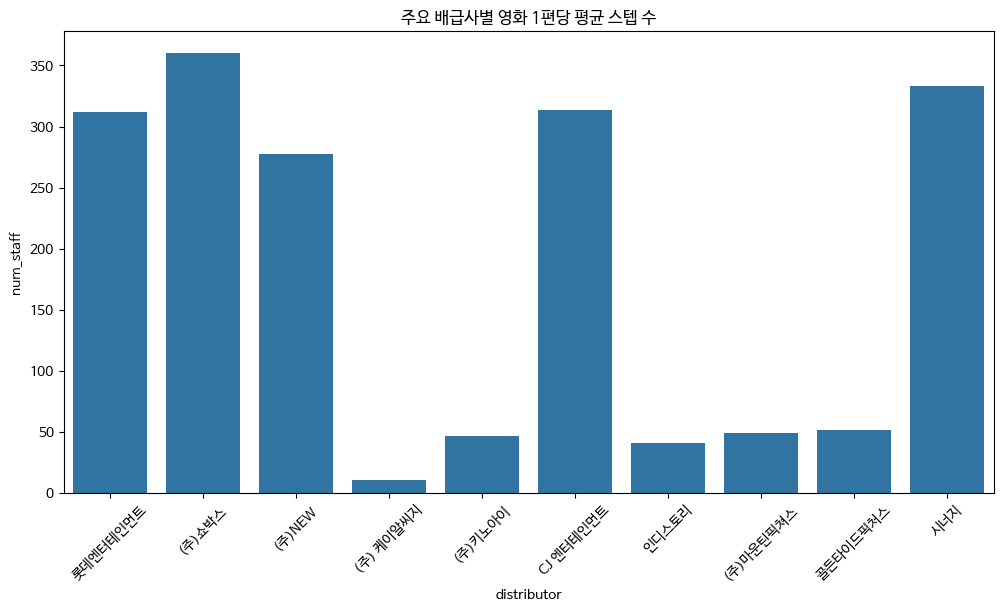

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(data=train_top10, x='distributor', y='num_staff', ci=None)
plt.title('주요 배급사별 영화 1편당 평균 스텝 수')
plt.xticks(rotation=45)
plt.show()

(2) 스텝 수 구간별 평균 관객수

"스텝이 많을 수록 관객수가 많을까?"

/tmp/ipykernel_1568/741311698.py:12: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=train, x='스텝수_구간', y='box_off_num', order=order, ci=None, palette='Blues')
/tmp/ipykernel_1568/741311698.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=train, x='스텝수_구간', y='box_off_num', order=order, ci=None, palette='Blues')


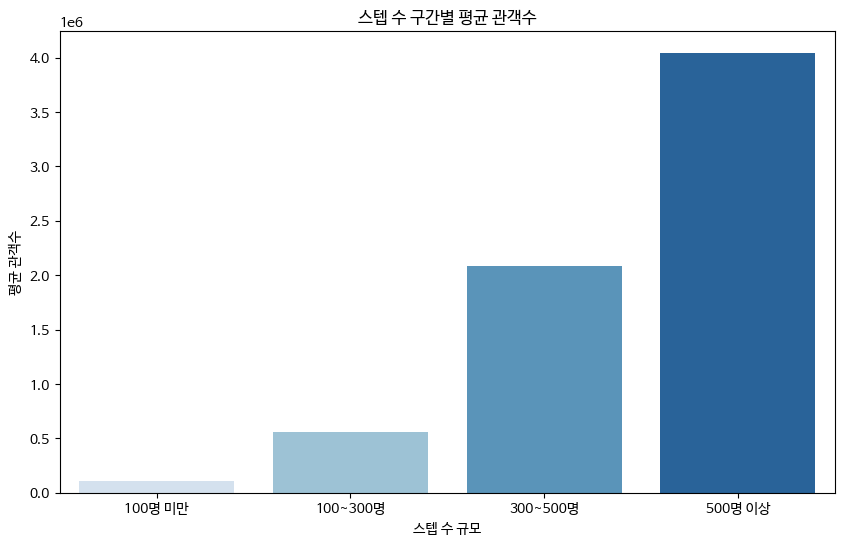

In [ ]:
def staff_band(staff):
    if staff < 100: return '100명 미만'
    elif staff < 300: return '100~300명'
    elif staff < 500: return '300~500명'
    else: return '500명 이상'

train['스텝수_구간'] = train['num_staff'].apply(staff_band)

order = ['100명 미만', '100~300명', '300~500명', '500명 이상']

plt.figure(figsize=(10, 6))
sns.barplot(data=train, x='스텝수_구간', y='box_off_num', order=order, ci=None, palette='Blues')

plt.title('스텝 수 구간별 평균 관객수')
plt.xlabel('스텝 수 규모')
plt.ylabel('평균 관객수')
plt.show()

(3) 배급사 수준별 관객수 분포

"대형 배급사 (상위 5개)와 기타 배급사의 흥행 규모에는 차이가 있을까?"

In [ ]:
# 1. 마운틴픽쳐스를 이상치로 처리한 후 제거
train_clean = train[train['distributor'] != '(주)마운틴픽쳐스'].copy()

# 2. 영화 제작 수 상위 4개 배급사
top4_list = train_clean['distributor'].value_counts().head(4).index

# 3. 나머지 배급사는 '기타'로 처리
train_clean['배급사_분류'] = train_clean['distributor'].apply(lambda x: x if x in top4_list else '기타')

print("--- 마운틴픽쳐스 제외 후 추출된 상위 4개사 ---")
print(list(top4_list))
print("\n--- 최종 그룹별 영화 개수 ---")
print(train_clean['배급사_분류'].value_counts())

--- 마운틴픽쳐스 제외 후 추출된 상위 4개사 ---
['CJ 엔터테인먼트', '롯데엔터테인먼트', '(주)NEW', '(주)쇼박스']

--- 최종 그룹별 영화 개수 ---
배급사_분류
기타           409
CJ 엔터테인먼트     54
롯데엔터테인먼트      52
(주)NEW        30
(주)쇼박스        26
Name: count, dtype: int64


/tmp/ipykernel_1568/1654954245.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=train_clean, x='배급사_분류', y='box_off_num', ci=None, palette='Set2', order=list(top4_list) + ['기타'])
/tmp/ipykernel_1568/1654954245.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=train_clean, x='배급사_분류', y='box_off_num', ci=None, palette='Set2', order=list(top4_list) + ['기타'])


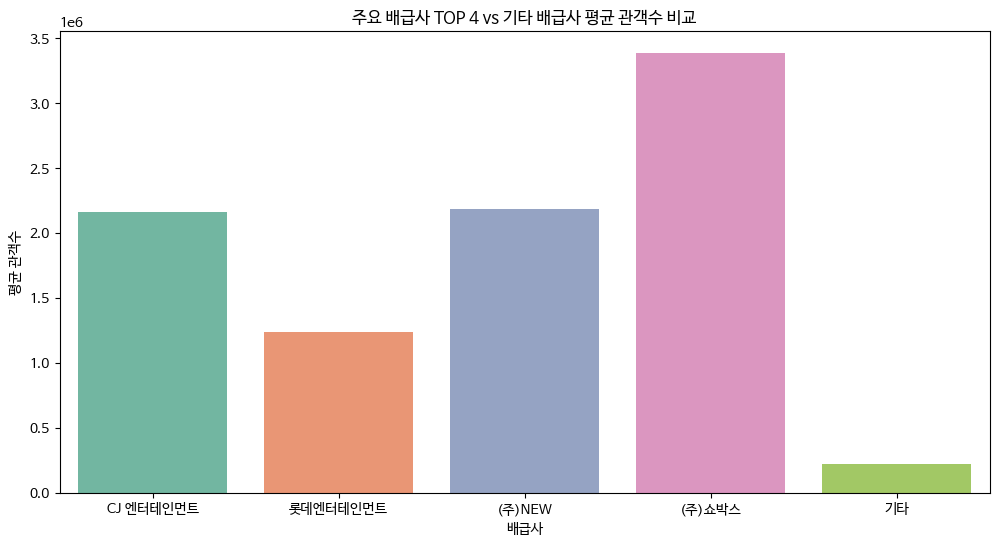

In [ ]:
plt.figure(figsize=(12, 6))

sns.barplot(data=train_clean, x='배급사_분류', y='box_off_num', ci=None, palette='Set2', order=list(top4_list) + ['기타'])
plt.title('주요 배급사 TOP 4 vs 기타 배급사 평균 관객수 비교')
plt.xlabel('배급사')
plt.ylabel('평균 관객수')
plt.show()

(4) 스텝수 상위 10개 영화

"스텝을 가장 많이 쓴 영화들은 관객이 얼마나 들었을까?"

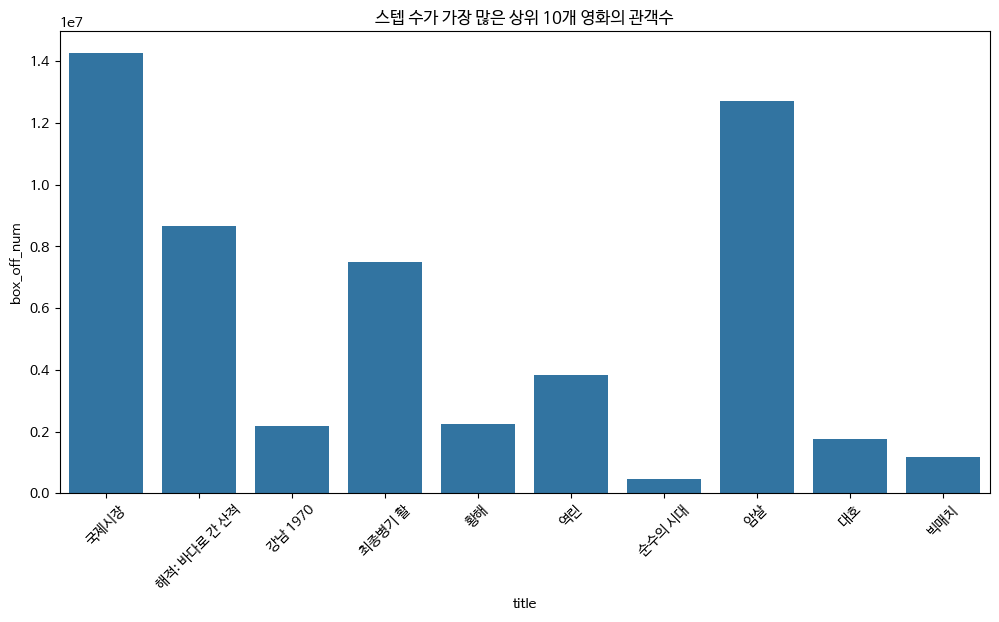

In [ ]:
# 스텝수가 가장 많은 상위 10개 영화 추출
top10_staff_movies = train.sort_values(by='num_staff', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top10_staff_movies, x='title', y='box_off_num')
plt.title('스텝 수가 가장 많은 상위 10개 영화의 관객수')
plt.xticks(rotation=45)
plt.show()